# Final Analysis Notebook
## Conflict Intensity and Apartment Rents Across Ukrainian Regions

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox, het_arch
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from scipy.stats import jarque_bera
from IPython.display import display

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

DATA_PATH = "rent_acled_with_lags.csv"   # change if needed
FIG_DIR = Path("figures")
TABLE_DIR = Path("tables")
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

## 1. Load and standardize data

In [2]:
def pick_column(columns, candidates, required=False):
    for c in candidates:
        if c in columns:
            return c
    if required:
        raise KeyError(f"Missing required column. Tried: {candidates}")
    return None

raw = pd.read_csv(DATA_PATH)

col_map = {
    "region": pick_column(raw.columns, ["region", "область"], required=True),
    "flat_type": pick_column(raw.columns, ["flat_type", "тип_квартири"], required=True),
    "rent_uah": pick_column(raw.columns, ["rent_uah", "середня_ціна_грн"], required=True),
    "month": pick_column(raw.columns, ["month"], required=True),
    "log_rent": pick_column(raw.columns, ["log_rent"]),
    "total_attacks": pick_column(raw.columns, ["total_attacks"]),
    "total_attacks_lag1": pick_column(raw.columns, ["total_attacks_lag1"]),
    "total_attacks_lag2": pick_column(raw.columns, ["total_attacks_lag2"]),
    "shelling_count": pick_column(raw.columns, ["shelling_count"]),
    "drone_count": pick_column(raw.columns, ["drone_count"]),
    "battle_count": pick_column(raw.columns, ["battle_count"]),
    "fatalities": pick_column(raw.columns, ["fatalities"]),
    "fatalities_lag1": pick_column(raw.columns, ["fatalities_lag1"]),
    "unemp_monthly": pick_column(raw.columns, ["unemp_monthly"]),
    "any_attack": pick_column(raw.columns, ["any_attack"]),
    "rent_lag1": pick_column(raw.columns, ["rent_lag1"]),
    "status": pick_column(raw.columns, ["status", "data_status"]),
}

df = raw.copy()

for std_name, original_name in col_map.items():
    if original_name is not None and std_name not in df.columns:
        df[std_name] = df[original_name]

df["region"] = df["region"].astype(str)
df["flat_type"] = df["flat_type"].astype(str)
df["month_dt"] = pd.to_datetime(df["month"])
df["month"] = df["month_dt"].dt.strftime("%Y-%m")

# period used in the report
df = df[(df["month_dt"] >= "2022-02-01") & (df["month_dt"] <= "2024-12-31")].copy()

if "log_rent" not in df.columns or df["log_rent"].isna().all():
    df["log_rent"] = np.log(df["rent_uah"])

if "any_attack" not in df.columns or df["any_attack"].isna().all():
    if "total_attacks" in df.columns:
        df["any_attack"] = (df["total_attacks"].fillna(0) > 0).astype(int)

if "rent_lag1" not in df.columns or df["rent_lag1"].isna().all():
    df = df.sort_values(["region", "flat_type", "month_dt"]).copy()
    df["rent_lag1"] = df.groupby(["region", "flat_type"])["rent_uah"].shift(1)

df["price_drop"] = np.where(df["rent_uah"] < df["rent_lag1"], 1, 0)
df["region_type"] = df["region"] + " | " + df["flat_type"]

print("Data loaded successfully.")
print("Shape:", df.shape)
print("Date range:", df["month_dt"].min().date(), "to", df["month_dt"].max().date())
print("Regions:", df["region"].nunique())
print("Apartment types:", sorted(df["flat_type"].dropna().unique().tolist()))

Data loaded successfully.
Shape: (2310, 27)
Date range: 2022-02-01 to 2024-12-01
Regions: 22
Apartment types: ['1-кімнатна квартира', '2-кімнатна квартира', '3-кімнатна квартира']


## 2. Quick data checks

In [3]:
overview = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "regions",
        "apartment_types",
        "start_month",
        "end_month",
        "mean_rent_uah",
        "median_rent_uah"
    ],
    "value": [
        len(df),
        df.shape[1],
        df["region"].nunique(),
        df["flat_type"].nunique(),
        df["month_dt"].min().strftime("%Y-%m"),
        df["month_dt"].max().strftime("%Y-%m"),
        round(df["rent_uah"].mean(), 2),
        round(df["rent_uah"].median(), 2)
    ]
})

missing_summary = (
    df[[
        c for c in [
            "rent_uah", "log_rent", "total_attacks", "total_attacks_lag1", "shelling_count",
            "drone_count", "battle_count", "fatalities", "unemp_monthly", "any_attack", "rent_lag1"
        ] if c in df.columns
    ]]
    .isna()
    .sum()
    .rename("missing_count")
    .reset_index()
    .rename(columns={"index": "variable"})
)
missing_summary["missing_share"] = (missing_summary["missing_count"] / len(df)).round(4)

display(overview)
display(missing_summary)

,metric,value
0,rows,2310
1,columns,27
2,regions,22
3,apartment_types,3
4,start_month,2022-02
5,end_month,2024-12
6,mean_rent_uah,9761.95
7,median_rent_uah,9396.0


,variable,missing_count,missing_share
0,rent_uah,7,0.0030
1,log_rent,7,0.0030
2,total_attacks,0,0.0000
3,total_attacks_lag1,66,0.0286
4,shelling_count,0,0.0000
5,drone_count,0,0.0000
6,battle_count,0,0.0000
7,fatalities,0,0.0000
8,unemp_monthly,0,0.0000
9,any_attack,0,0.0000


## 3. Helper functions

In [4]:
def sort_flat_types(values):
    values = list(pd.Series(values).dropna().astype(str).unique())
    def key_func(x):
        digits = "".join(ch for ch in x if ch.isdigit())
        return (0, int(digits)) if digits else (1, x)
    return sorted(values, key=key_func)

def fit_clustered_ols(data, x_vars):
    needed = ["log_rent", "region", "month", "flat_type", "region_type"] + x_vars
    d = data[needed].dropna().copy()
    formula = "log_rent ~ " + " + ".join(x_vars) + " + C(region) + C(month) + C(flat_type)"
    model = smf.ols(formula=formula, data=d).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["region_type"]}
    )
    return model, d

def fit_plain_ols(data, x_vars):
    needed = ["log_rent", "region", "month", "flat_type"] + x_vars
    d = data[needed].dropna().copy()
    formula = "log_rent ~ " + " + ".join(x_vars) + " + C(region) + C(month) + C(flat_type)"
    model = smf.ols(formula=formula, data=d).fit()
    return model, d

def one_sided_left_test(model, var, alpha=0.05):
    coef = model.params[var]
    p_two = model.pvalues[var]
    if coef < 0:
        p_one = p_two / 2
    else:
        p_one = 1 - (p_two / 2)
    return {
        "variable": var,
        "coef": coef,
        "two_sided_p": p_two,
        "one_sided_p_beta_lt_0": p_one,
        "decision_5pct": "Reject H0" if (coef < 0 and p_one < alpha) else "Fail to reject H0"
    }

def percent_effect(beta, se, scale=1):
    low = beta - 1.96 * se
    high = beta + 1.96 * se
    effect = 100 * (np.exp(beta * scale) - 1)
    low_eff = 100 * (np.exp(low * scale) - 1)
    high_eff = 100 * (np.exp(high * scale) - 1)
    return effect, low_eff, high_eff

def make_binned_relationship(data, x_col, y_col, q=8):
    d = data[[x_col, y_col]].dropna().copy()
    try:
        d["bin"] = pd.qcut(d[x_col], q=q, duplicates="drop")
        out = d.groupby("bin", observed=False).agg(
            x_mean=(x_col, "mean"),
            y_mean=(y_col, "mean")
        ).reset_index(drop=True)
    except ValueError:
        out = d.groupby(x_col).agg(
            x_mean=(x_col, "mean"),
            y_mean=(y_col, "mean")
        ).reset_index(drop=True)
    return out

def display_main_coefs(model, keep_vars, model_name):
    table = pd.DataFrame({
        "coef": model.params,
        "std_err": model.bse,
        "p_value": model.pvalues
    }).loc[keep_vars].copy()
    table["model"] = model_name
    table["pct_effect_per_unit"] = 100 * (np.exp(table["coef"]) - 1)
    return table.reset_index().rename(columns={"index": "variable"})

def breusch_pagan_table(model, data, x_vars):
    X = add_constant(data[x_vars], has_constant="add").astype(float)
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_breuschpagan(model.resid, X)
    return pd.DataFrame([{
        "LM_stat": lm_stat,
        "LM_pvalue": lm_pvalue,
        "F_stat": f_stat,
        "F_pvalue": f_pvalue
    }])

def vif_table(data, x_vars):
    X = add_constant(data[x_vars], has_constant="add").astype(float)
    rows = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        rows.append({"variable": col, "VIF": variance_inflation_factor(X.values, i)})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False).reset_index(drop=True)

## 4. Descriptive analysis

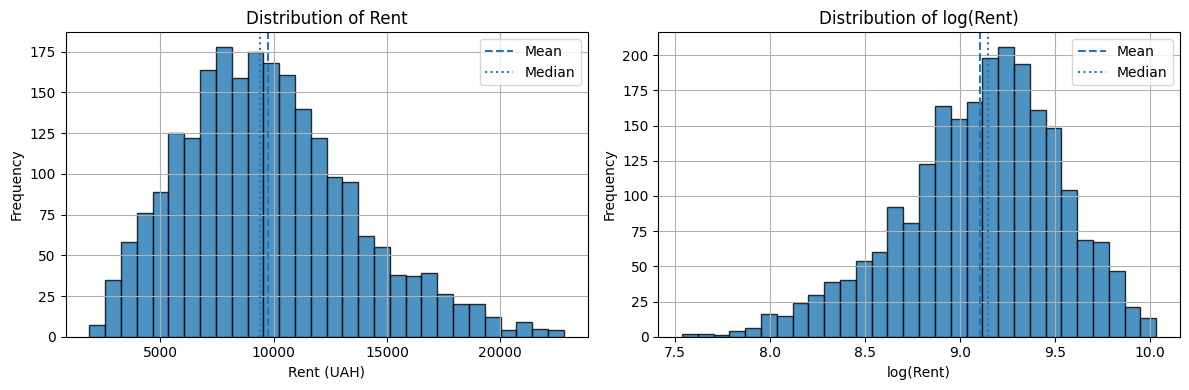

In [5]:
# Figure 1. Distribution of rent and log(rent)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["rent_uah"].dropna(), bins=30, edgecolor="black", alpha=0.8)
axes[0].axvline(df["rent_uah"].mean(), linestyle="--", label="Mean")
axes[0].axvline(df["rent_uah"].median(), linestyle=":", label="Median")
axes[0].set_title("Distribution of Rent")
axes[0].set_xlabel("Rent (UAH)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(df["log_rent"].dropna(), bins=30, edgecolor="black", alpha=0.8)
axes[1].axvline(df["log_rent"].mean(), linestyle="--", label="Mean")
axes[1].axvline(df["log_rent"].median(), linestyle=":", label="Median")
axes[1].set_title("Distribution of log(Rent)")
axes[1].set_xlabel("log(Rent)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_distribution_rent_and_logrent.png", dpi=300, bbox_inches="tight")
plt.show()

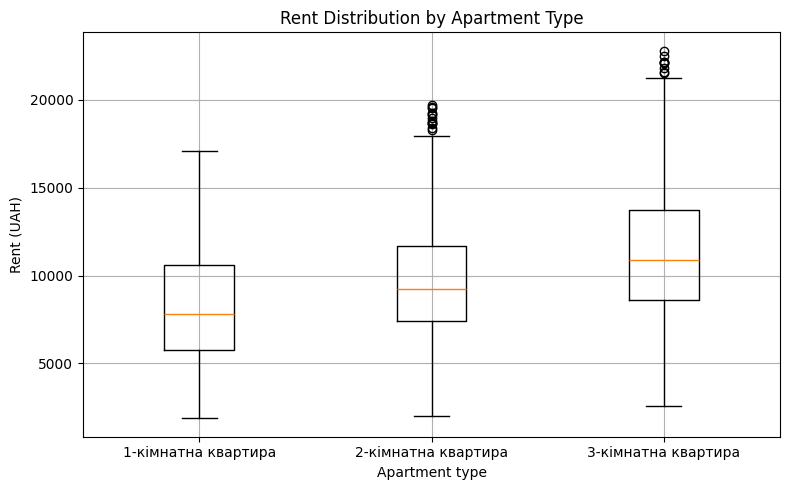

In [6]:
# Figure 2. Rent distribution by apartment type
flat_order = sort_flat_types(df["flat_type"])
box_data = [df.loc[df["flat_type"] == ft, "rent_uah"].dropna() for ft in flat_order]

plt.figure(figsize=(8, 5))
plt.boxplot(box_data, labels=flat_order)
plt.title("Rent Distribution by Apartment Type")
plt.xlabel("Apartment type")
plt.ylabel("Rent (UAH)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_rent_distribution_by_apartment_type.png", dpi=300, bbox_inches="tight")
plt.show()

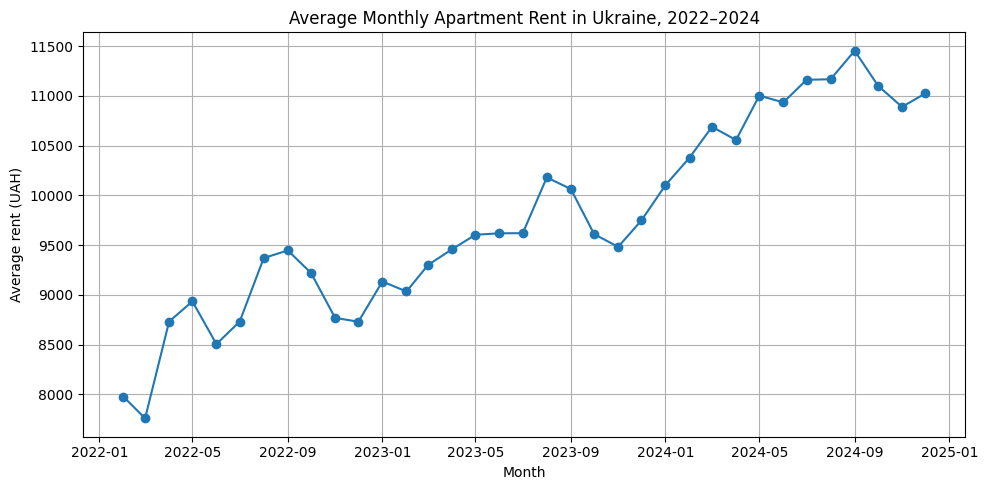

In [7]:
# Figure 3. Average monthly apartment rent in Ukraine
monthly_rent = (
    df.groupby("month_dt", as_index=False)["rent_uah"]
    .mean()
    .sort_values("month_dt")
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_rent["month_dt"], monthly_rent["rent_uah"], marker="o")
plt.title("Average Monthly Apartment Rent in Ukraine, 2022–2024")
plt.xlabel("Month")
plt.ylabel("Average rent (UAH)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_average_monthly_rent_ukraine.png", dpi=300, bbox_inches="tight")
plt.show()

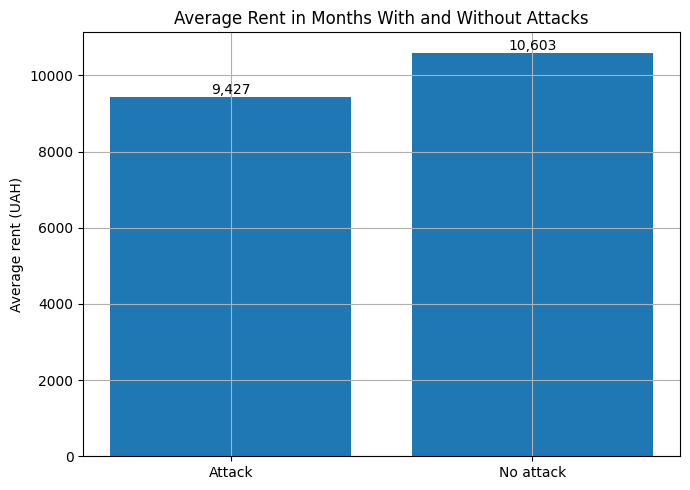

In [8]:
# Figure 4. Average rent in months with and without attacks
attack_bar = (
    df.assign(attack_label=np.where(df["any_attack"] == 1, "Attack", "No attack"))
      .groupby("attack_label", as_index=False)["rent_uah"]
      .mean()
)

plt.figure(figsize=(7, 5))
bars = plt.bar(attack_bar["attack_label"], attack_bar["rent_uah"])
plt.title("Average Rent in Months With and Without Attacks")
plt.ylabel("Average rent (UAH)")

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{h:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_attack_vs_no_attack_rent.png", dpi=300, bbox_inches="tight")
plt.show()

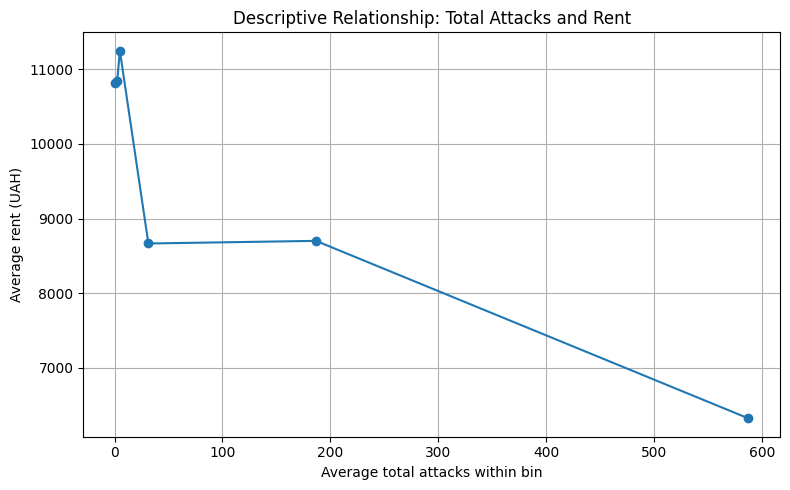

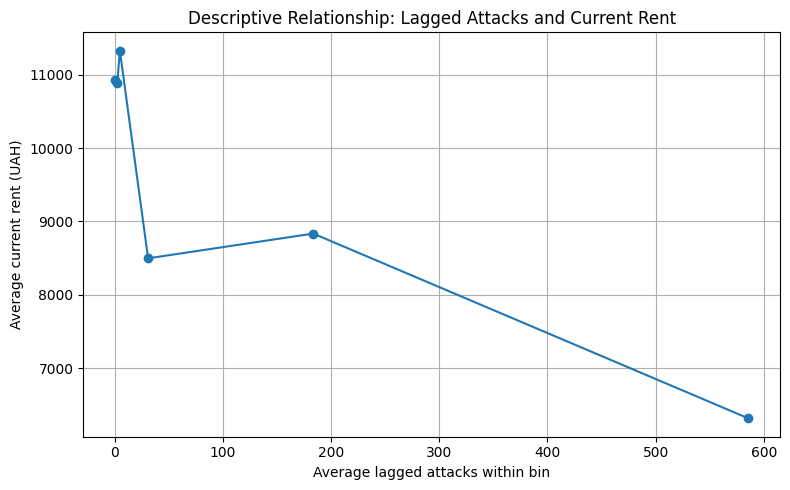

In [9]:
# Figures 5 and 6. Binned descriptive relationships
if "total_attacks" in df.columns:
    binned_current = make_binned_relationship(df, "total_attacks", "rent_uah", q=8)

    plt.figure(figsize=(8, 5))
    plt.plot(binned_current["x_mean"], binned_current["y_mean"], marker="o")
    plt.title("Descriptive Relationship: Total Attacks and Rent")
    plt.xlabel("Average total attacks within bin")
    plt.ylabel("Average rent (UAH)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig5_binned_total_attacks_rent.png", dpi=300, bbox_inches="tight")
    plt.show()

if "total_attacks_lag1" in df.columns:
    binned_lag = make_binned_relationship(df, "total_attacks_lag1", "rent_uah", q=8)

    plt.figure(figsize=(8, 5))
    plt.plot(binned_lag["x_mean"], binned_lag["y_mean"], marker="o")
    plt.title("Descriptive Relationship: Lagged Attacks and Current Rent")
    plt.xlabel("Average lagged attacks within bin")
    plt.ylabel("Average current rent (UAH)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig6_binned_lagged_attacks_rent.png", dpi=300, bbox_inches="tight")
    plt.show()

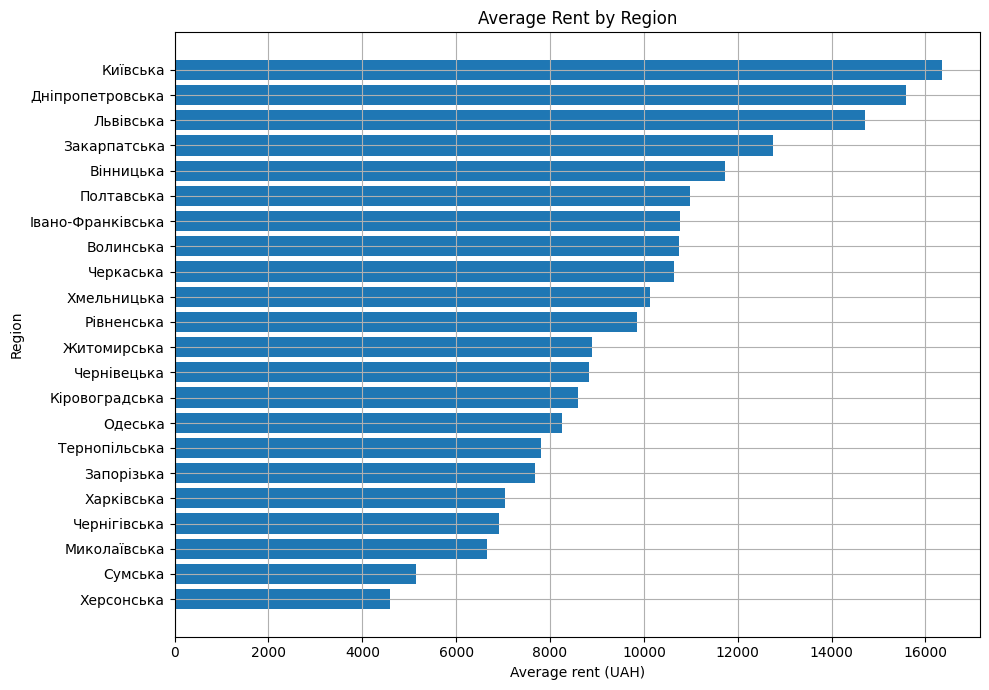

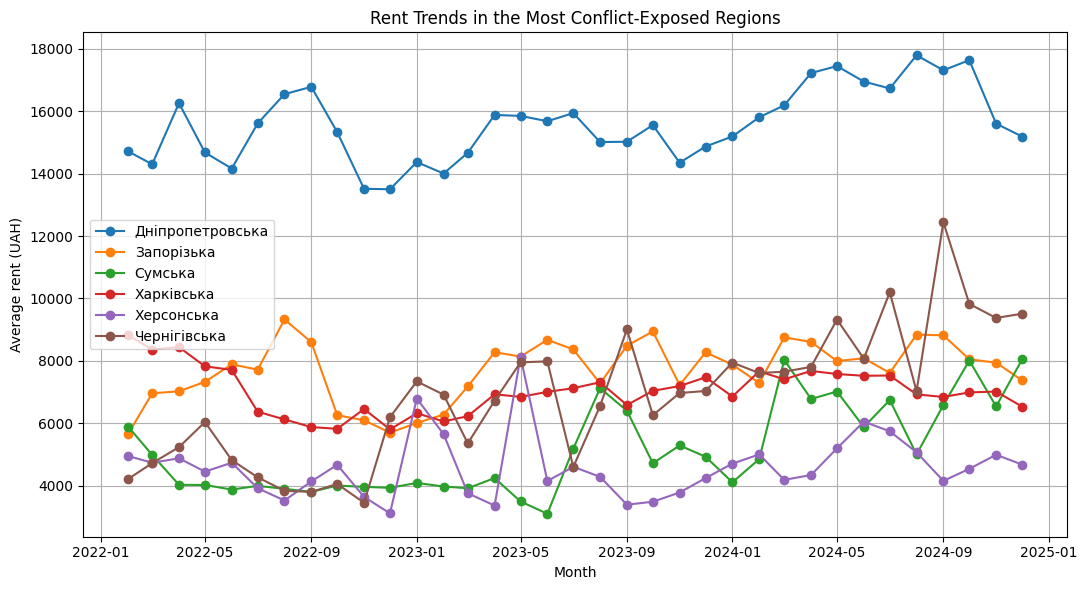

In [10]:
# Figures 9 and 10. Regional descriptive plots
avg_rent_by_region = (
    df.groupby("region", as_index=False)["rent_uah"]
    .mean()
    .sort_values("rent_uah", ascending=True)
)

plt.figure(figsize=(10, 7))
plt.barh(avg_rent_by_region["region"], avg_rent_by_region["rent_uah"])
plt.title("Average Rent by Region")
plt.xlabel("Average rent (UAH)")
plt.ylabel("Region")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig9_average_rent_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

preferred_regions = ["Харківська", "Сумська", "Запорізька", "Херсонська", "Чернігівська", "Дніпропетровська"]
available_preferred = [r for r in preferred_regions if r in set(df["region"])]

if len(available_preferred) >= 3:
    focus_regions = available_preferred
else:
    focus_regions = (
        df.groupby("region")["total_attacks"]
          .mean()
          .sort_values(ascending=False)
          .head(6)
          .index
          .tolist()
    )

trend_df = (
    df[df["region"].isin(focus_regions)]
    .groupby(["month_dt", "region"], as_index=False)["rent_uah"]
    .mean()
)

plt.figure(figsize=(11, 6))
for region_name, grp in trend_df.groupby("region"):
    plt.plot(grp["month_dt"], grp["rent_uah"], marker="o", linewidth=1.5, label=region_name)

plt.title("Rent Trends in the Most Conflict-Exposed Regions")
plt.xlabel("Month")
plt.ylabel("Average rent (UAH)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig10_rent_trends_conflict_exposed_regions.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Panel OLS models

In [11]:
# Model 1. Current conflict intensity
model_1, model_1_df = fit_clustered_ols(df, ["total_attacks", "fatalities", "unemp_monthly"])

# Model 2. Lagged attacks
model_2, model_2_df = fit_clustered_ols(df, ["total_attacks_lag1", "fatalities", "unemp_monthly"])

# Model 3. Attack composition
model_3, model_3_df = fit_clustered_ols(df, ["shelling_count", "drone_count", "battle_count", "fatalities", "unemp_monthly"])

# Model 4. Attack dummy
model_4, model_4_df = fit_clustered_ols(df, ["any_attack", "fatalities", "unemp_monthly"])

print("Model 1 fitted on", len(model_1_df), "rows")
print("Model 2 fitted on", len(model_2_df), "rows")
print("Model 3 fitted on", len(model_3_df), "rows")
print("Model 4 fitted on", len(model_4_df), "rows")

Model 1 fitted on 2303 rows
Model 2 fitted on 2240 rows
Model 3 fitted on 2303 rows
Model 4 fitted on 2303 rows


## 6. Hypothesis checks

In [12]:
ols_tables = pd.concat([
    display_main_coefs(model_1, ["total_attacks", "fatalities", "unemp_monthly"], "Model 1: current attacks"),
    display_main_coefs(model_2, ["total_attacks_lag1", "fatalities", "unemp_monthly"], "Model 2: lagged attacks"),
    display_main_coefs(model_3, ["shelling_count", "drone_count", "battle_count", "fatalities", "unemp_monthly"], "Model 3: composition"),
    display_main_coefs(model_4, ["any_attack", "fatalities", "unemp_monthly"], "Model 4: attack dummy")
], ignore_index=True)

display(ols_tables)
ols_tables.to_csv(TABLE_DIR / "ols_main_coefficients.csv", index=False)

,variable,coef,std_err,p_value,model,pct_effect_per_unit
0,total_attacks,2.293725e-05,0.000106,0.829242,Model 1: current attacks,0.002294
1,fatalities,-4.275385e-05,0.000041,0.294485,Model 1: current attacks,-0.004275
2,unemp_monthly,-1.955476e-07,0.000005,0.967595,Model 1: current attacks,-0.000020
3,total_attacks_lag1,6.069013e-05,0.000108,0.575013,Model 2: lagged attacks,0.006069
4,fatalities,-3.129967e-05,0.000041,0.447515,Model 2: lagged attacks,-0.003130
5,unemp_monthly,-6.077680e-07,0.000005,0.900302,Model 2: lagged attacks,-0.000061
6,shelling_count,-1.191054e-04,0.000093,0.201691,Model 3: composition,-0.011910
7,drone_count,2.506632e-04,0.000115,0.029454,Model 3: composition,0.025069
8,battle_count,-6.840519e-04,0.000187,0.000262,Model 3: composition,-0.068382
9,fatalities,-7.197030e-06,0.000043,0.867087,Model 3: composition,-0.000720


In [13]:
alpha = 0.05

hypothesis_results = pd.DataFrame([
    {"hypothesis": "H1: current attacks lower rent", **one_sided_left_test(model_1, "total_attacks", alpha)},
    {"hypothesis": "H1: fatalities lower rent", **one_sided_left_test(model_1, "fatalities", alpha)},
    {"hypothesis": "H1: unemployment lowers rent", **one_sided_left_test(model_1, "unemp_monthly", alpha)},
    {"hypothesis": "H1: lagged attacks lower rent", **one_sided_left_test(model_2, "total_attacks_lag1", alpha)},
    {"hypothesis": "H1: months with attacks have lower rent", **one_sided_left_test(model_4, "any_attack", alpha)}
])

joint_test = model_3.f_test("shelling_count = drone_count, drone_count = battle_count")
joint_row = pd.DataFrame([{
    "hypothesis": "H1: shelling, drone, and battle effects differ",
    "variable": "shelling_count = drone_count = battle_count",
    "coef": np.nan,
    "two_sided_p": float(joint_test.pvalue),
    "one_sided_p_beta_lt_0": np.nan,
    "decision_5pct": "Reject H0" if float(joint_test.pvalue) < alpha else "Fail to reject H0"
}])

hypothesis_results = pd.concat([hypothesis_results, joint_row], ignore_index=True)
display(hypothesis_results)
hypothesis_results.to_csv(TABLE_DIR / "hypothesis_results.csv", index=False)

,hypothesis,variable,coef,two_sided_p,one_sided_p_beta_lt_0,decision_5pct
0,H1: current attacks lower rent,total_attacks,2.293725e-05,0.829242,0.585379,Fail to reject H0
1,H1: fatalities lower rent,fatalities,-4.275385e-05,0.294485,0.147243,Fail to reject H0
2,H1: unemployment lowers rent,unemp_monthly,-1.955476e-07,0.967595,0.483797,Fail to reject H0
3,H1: lagged attacks lower rent,total_attacks_lag1,6.069013e-05,0.575013,0.712493,Fail to reject H0
4,H1: months with attacks have lower rent,any_attack,-6.180464e-03,0.532137,0.266069,Fail to reject H0
5,"H1: shelling, drone, and battle effects differ",shelling_count = drone_count = battle_count,NaN,0.000657,NaN,Reject H0


In [14]:
print(model_1.summary())
print(model_2.summary())
print(model_3.summary())
print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:               log_rent   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     8528.
Date:                Sat, 18 Apr 2026   Prob (F-statistic):          7.10e-110
Time:                        19:04:36   Log-Likelihood:                 627.71
No. Observations:                2303   AIC:                            -1133.
Df Residuals:                    2242   BIC:                            -783.2
Df Model:                          60                                         
Covariance Type:              cluster                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

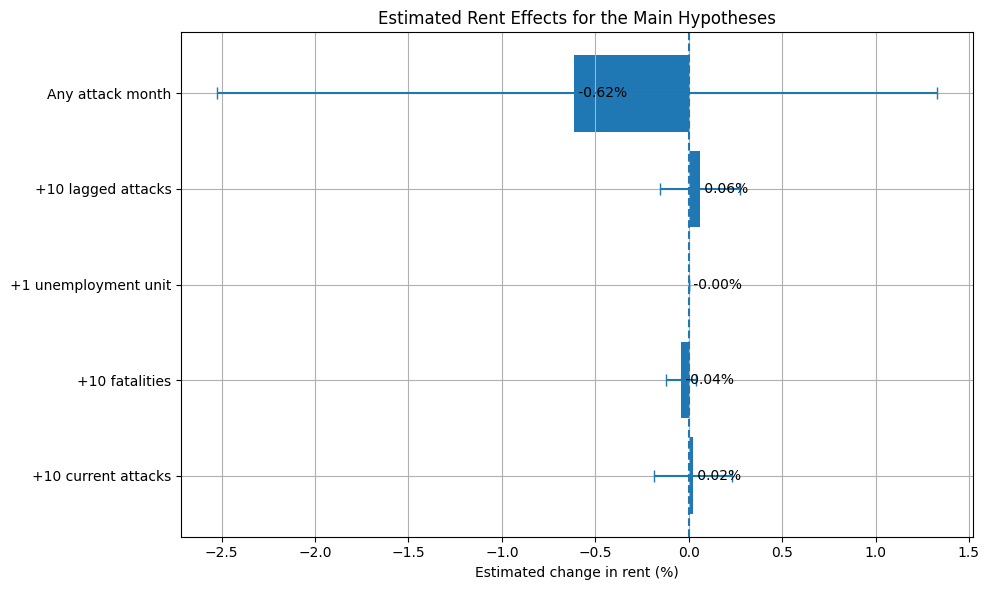

In [15]:
# Figure 7. Estimated rent effects for the main hypotheses
main_specs = [
    ("+10 current attacks", model_1, "total_attacks", 10),
    ("+10 fatalities", model_1, "fatalities", 10),
    ("+1 unemployment unit", model_1, "unemp_monthly", 1),
    ("+10 lagged attacks", model_2, "total_attacks_lag1", 10),
    ("Any attack month", model_4, "any_attack", 1),
]

main_rows = []
for label, model, var, scale in main_specs:
    eff, low, high = percent_effect(model.params[var], model.bse[var], scale)
    main_rows.append({"label": label, "effect": eff, "low": low, "high": high})

main_effects_df = pd.DataFrame(main_rows)

plt.figure(figsize=(10, 6))
y = np.arange(len(main_effects_df))
plt.barh(y, main_effects_df["effect"])
plt.errorbar(
    main_effects_df["effect"], y,
    xerr=[main_effects_df["effect"] - main_effects_df["low"], main_effects_df["high"] - main_effects_df["effect"]],
    fmt="none",
    capsize=4
)
plt.axvline(0, linestyle="--")
plt.yticks(y, main_effects_df["label"])
plt.xlabel("Estimated change in rent (%)")
plt.title("Estimated Rent Effects for the Main Hypotheses")

for i, v in enumerate(main_effects_df["effect"]):
    plt.text(v, i, f" {v:.2f}%", va="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_main_effects_percent_bar.png", dpi=300, bbox_inches="tight")
plt.show()

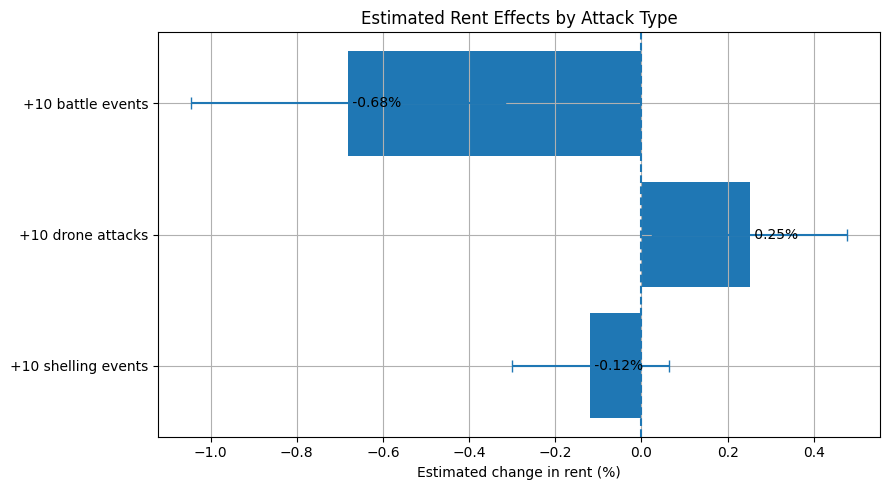

In [16]:
# Figure 8. Estimated rent effects by attack type
comp_specs = [
    ("+10 shelling events", model_3, "shelling_count", 10),
    ("+10 drone attacks", model_3, "drone_count", 10),
    ("+10 battle events", model_3, "battle_count", 10),
]

comp_rows = []
for label, model, var, scale in comp_specs:
    eff, low, high = percent_effect(model.params[var], model.bse[var], scale)
    comp_rows.append({"label": label, "effect": eff, "low": low, "high": high})

comp_effects_df = pd.DataFrame(comp_rows)

plt.figure(figsize=(9, 5))
y = np.arange(len(comp_effects_df))
plt.barh(y, comp_effects_df["effect"])
plt.errorbar(
    comp_effects_df["effect"], y,
    xerr=[comp_effects_df["effect"] - comp_effects_df["low"], comp_effects_df["high"] - comp_effects_df["effect"]],
    fmt="none",
    capsize=4
)
plt.axvline(0, linestyle="--")
plt.yticks(y, comp_effects_df["label"])
plt.xlabel("Estimated change in rent (%)")
plt.title("Estimated Rent Effects by Attack Type")

for i, v in enumerate(comp_effects_df["effect"]):
    plt.text(v, i, f" {v:.2f}%", va="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig8_attack_composition_percent_bar.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Diagnostic checks

In [17]:
diagnostic_specs = {
    "Model 1: current conflict intensity": ["total_attacks", "fatalities", "unemp_monthly"],
    "Model 2: lagged attacks": ["total_attacks_lag1", "fatalities", "unemp_monthly"],
    "Model 3: attack composition": ["shelling_count", "drone_count", "battle_count", "fatalities", "unemp_monthly"],
    "Model 4: attack dummy": ["any_attack", "fatalities", "unemp_monthly"]
}

bp_tables = []
vif_tables = []

for model_name, x_vars in diagnostic_specs.items():
    plain_model, d_plain = fit_plain_ols(df, x_vars)
    bp_res = breusch_pagan_table(plain_model, d_plain, x_vars)
    bp_res.insert(0, "model", model_name)
    bp_tables.append(bp_res)

    vif_res = vif_table(d_plain, x_vars)
    vif_res.insert(0, "model", model_name)
    vif_tables.append(vif_res)

bp_all = pd.concat(bp_tables, ignore_index=True)
vif_all = pd.concat(vif_tables, ignore_index=True)

display(bp_all)
display(vif_all)

bp_all.to_csv(TABLE_DIR / "breusch_pagan_results.csv", index=False)
vif_all.to_csv(TABLE_DIR / "vif_results.csv", index=False)

,model,LM_stat,LM_pvalue,F_stat,F_pvalue
0,Model 1: current conflict intensity,42.206312,3.627366e-09,14.306526,3.091942e-09
1,Model 2: lagged attacks,32.598778,3.913482e-07,11.007041,3.571688e-07
2,Model 3: attack composition,54.556890,1.610165e-10,11.147018,1.241711e-10
3,Model 4: attack dummy,28.698072,2.591616e-06,9.669907,2.426132e-06


,model,variable,VIF
0,Model 1: current conflict intensity,total_attacks,1.489418
1,Model 1: current conflict intensity,fatalities,1.408665
2,Model 1: current conflict intensity,unemp_monthly,1.081295
3,Model 2: lagged attacks,total_attacks_lag1,1.454002
4,Model 2: lagged attacks,fatalities,1.368856
5,Model 2: lagged attacks,unemp_monthly,1.082996
6,Model 3: attack composition,fatalities,1.692999
7,Model 3: attack composition,shelling_count,1.689490
8,Model 3: attack composition,battle_count,1.591956
9,Model 3: attack composition,drone_count,1.327434


## 8. Logit model

In [18]:
logit_data = df[
    ["price_drop", "total_attacks", "fatalities", "unemp_monthly", "region", "month", "flat_type", "rent_lag1"]
].dropna().copy()

print("Logit sample size:", logit_data.shape[0])
print(logit_data["price_drop"].value_counts(dropna=False))

Logit sample size: 2237
price_drop
0    1162
1    1075
Name: count, dtype: int64


In [19]:
logit_model = smf.glm(
    formula="price_drop ~ total_attacks + fatalities + unemp_monthly + C(region) + C(month) + C(flat_type)",
    data=logit_data,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": logit_data["region"]}
)

print(logit_model.summary())

logit_coef_table = pd.DataFrame({
    "coef": logit_model.params,
    "std_err": logit_model.bse,
    "z_stat": logit_model.params / logit_model.bse,
    "p_value": logit_model.pvalues,
    "odds_ratio": np.exp(logit_model.params)
})

main_logit = logit_coef_table.loc[["total_attacks", "fatalities", "unemp_monthly"]].reset_index()
main_logit = main_logit.rename(columns={"index": "variable"})

display(main_logit)
main_logit.to_csv(TABLE_DIR / "logit_main_coefficients.csv", index=False)

                 Generalized Linear Model Regression Results                  
Dep. Variable:             price_drop   No. Observations:                 2237
Model:                            GLM   Df Residuals:                     2177
Model Family:                Binomial   Df Model:                           59
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1489.2
Date:                Sat, 18 Apr 2026   Deviance:                       2978.5
Time:                        19:04:37   Pearson chi2:                 2.24e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.05192
Covariance Type:              cluster                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

,variable,coef,std_err,z_stat,p_value,odds_ratio
0,total_attacks,-0.000024,0.000611,-0.039662,0.968363,0.999976
1,fatalities,-0.000251,0.000244,-1.028327,0.303796,0.999749
2,unemp_monthly,0.000021,0.000017,1.239384,0.215203,1.000021


## 9. ARIMA model

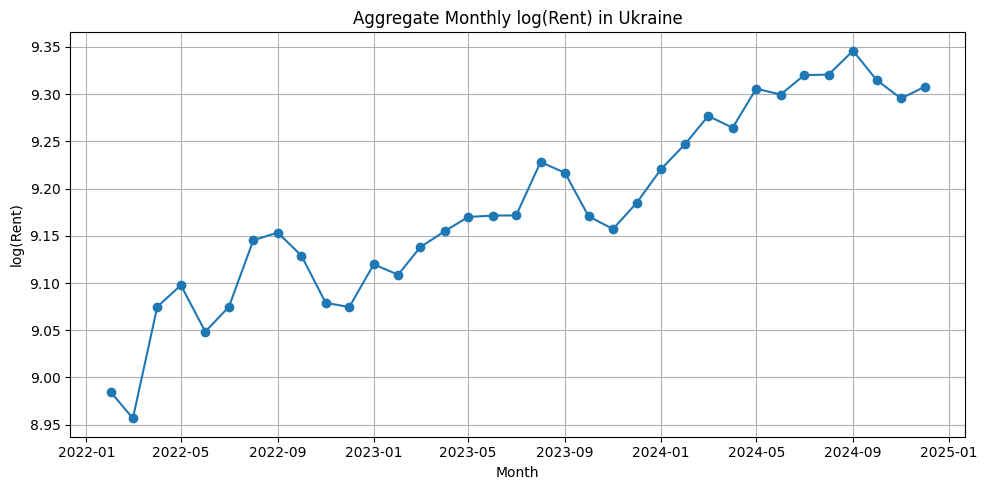

ADF statistic: -1.62883430050726
ADF p-value: 0.4681009457664062
Chosen differencing order d = 1


In [20]:
monthly = (
    df.dropna(subset=["rent_uah"])
      .groupby("month_dt", as_index=False)["rent_uah"]
      .mean()
      .sort_values("month_dt")
      .copy()
)

monthly["log_rent"] = np.log(monthly["rent_uah"])

plt.figure(figsize=(10, 5))
plt.plot(monthly["month_dt"], monthly["log_rent"], marker="o")
plt.title("Aggregate Monthly log(Rent) in Ukraine")
plt.xlabel("Month")
plt.ylabel("log(Rent)")
plt.tight_layout()
plt.savefig(FIG_DIR / "arima_log_rent_series.png", dpi=300, bbox_inches="tight")
plt.show()

adf_stat, adf_pvalue, *_ = adfuller(monthly["log_rent"])
d = 0 if adf_pvalue < 0.05 else 1

print("ADF statistic:", adf_stat)
print("ADF p-value:", adf_pvalue)
print("Chosen differencing order d =", d)

In [21]:
best_aic = np.inf
best_order = None
best_model = None

for p in range(3):
    for q in range(3):
        try:
            model = ARIMA(monthly["log_rent"], order=(p, d, q))
            result = model.fit()
            if result.aic < best_aic:
                best_aic = result.aic
                best_order = (p, d, q)
                best_model = result
        except Exception:
            continue

print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)
print(best_model.summary())

Best ARIMA order: (2, 1, 0)
Best AIC: -128.30961615956565
                               SARIMAX Results                                
Dep. Variable:               log_rent   No. Observations:                   35
Model:                 ARIMA(2, 1, 0)   Log Likelihood                  67.155
Date:                Sat, 18 Apr 2026   AIC                           -128.310
Time:                        19:04:37   BIC                           -123.731
Sample:                             0   HQIC                          -126.748
                                 - 35                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0873      0.279      0.313      0.754      -0.459       0.634
ar.L2         -0.4186      0.186     -2.247      0.025      -0.784      -

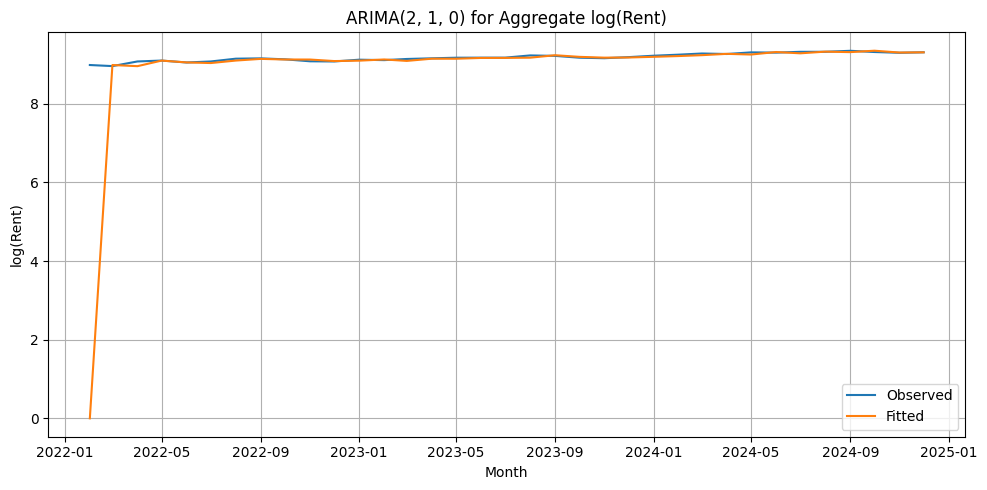

,test,statistic,p_value
0,ADF,-1.628834,0.468101
1,Ljung-Box,0.011486,1.000000
2,Jarque-Bera,1499.067395,0.000000
3,ARCH heteroskedasticity,7.097789,0.418770


In [22]:
monthly["fitted"] = best_model.predict()

plt.figure(figsize=(10, 5))
plt.plot(monthly["month_dt"], monthly["log_rent"], label="Observed")
plt.plot(monthly["month_dt"], monthly["fitted"], label="Fitted")
plt.title(f"ARIMA{best_order} for Aggregate log(Rent)")
plt.xlabel("Month")
plt.ylabel("log(Rent)")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "arima_observed_vs_fitted.png", dpi=300, bbox_inches="tight")
plt.show()

resid = pd.Series(best_model.resid).dropna()

lb_df = acorr_ljungbox(resid, lags=[min(10, max(1, len(resid) // 4))], return_df=True)
jb_stat, jb_pvalue = jarque_bera(resid)
arch_stat, arch_pvalue, _, _ = het_arch(resid)

arima_diag = pd.DataFrame({
    "test": ["ADF", "Ljung-Box", "Jarque-Bera", "ARCH heteroskedasticity"],
    "statistic": [
        adf_stat,
        lb_df["lb_stat"].iloc[0],
        jb_stat,
        arch_stat
    ],
    "p_value": [
        adf_pvalue,
        lb_df["lb_pvalue"].iloc[0],
        jb_pvalue,
        arch_pvalue
    ]
})

display(arima_diag)
arima_diag.to_csv(TABLE_DIR / "arima_diagnostics.csv", index=False)

## 10. Saved outputs
Figures are saved to the `figures/` folder

Tables are saved to the `tables/` folder